# Comparativa de modelos - Regresión

Objetivo: comparar dos versiones de cada modelo de regresión usando validación cruzada y un conjunto holdout sobre Housing Prices.

## 1) Librerías

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn


In [2]:
# Importamos sklearn y las herramientas necesarias para repetir el mismo flujo que en clasificación.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import get_scorer

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor


## 2) Cargar datos

In [3]:
data = pd.read_csv("housing.csv")
data.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## 3) Preparar datos

In [5]:
variables_a_descartar = []
variables_categoricas = ["CHAS"]
variables_numericas = [
    "CRIM", "ZN", "INDUS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]
variable_dependiente = "MEDV"

X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente].astype(float)

print(X.head())
print(y.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  
0     15.3  396.90   4.98  
1     17.8  396.90   9.14  
2     17.8  392.83   4.03  
3     18.7  394.63   2.94  
4     18.7  396.90   5.33  
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


## 4) Definir holdout y métricas

In [6]:
random_state = 42
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

# En sklearn varios errores se reportan con signo negativo para que "más alto" siga significando "mejor".
metricas_disponibles = ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error", "neg_mean_absolute_percentage_error"]
metricas_seleccionadas = ["r2", "neg_root_mean_squared_error"]

for metrica in metricas_seleccionadas:
    if metrica not in metricas_disponibles:
        raise ValueError(f"La métrica {metrica} no está en la lista disponible")

scoring = {metrica: metrica for metrica in metricas_seleccionadas}
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)


## 5) Grilla de comparación

In [7]:
preprocesamiento = ColumnTransformer([
    (
        "numerico",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        variables_numericas,
    ),
    (
        "categorico",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        variables_categoricas,
    ),
])

comparison_grid = [
    {"modelo": "KNN", "version": "k=5", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsRegressor(n_neighbors=5))])},
    {"modelo": "KNN", "version": "k=11", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsRegressor(n_neighbors=11))])},
    {"modelo": "Regresión lineal", "version": "OLS", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", LinearRegression())])},
    {"modelo": "Regresión lineal", "version": "Ridge(alpha=1)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", Ridge(alpha=1.0, random_state=random_state))])},
    {"modelo": "Árbol de decisión", "version": "max_depth=4", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", DecisionTreeRegressor(max_depth=4, random_state=random_state))])},
    {"modelo": "Árbol de decisión", "version": "max_depth=8", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", DecisionTreeRegressor(max_depth=8, random_state=random_state))])},
    {"modelo": "Random forest", "version": "200 árboles", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", RandomForestRegressor(n_estimators=200, random_state=random_state))])},
    {"modelo": "Random forest", "version": "400 árboles", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", RandomForestRegressor(n_estimators=400, random_state=random_state))])},
    {"modelo": "SVM", "version": "C=1", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVR(C=1.0, kernel="rbf", epsilon=0.1))])},
    {"modelo": "SVM", "version": "C=10", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVR(C=10.0, kernel="rbf", epsilon=0.1))])},
    {"modelo": "Red neuronal", "version": "(32,)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", MLPRegressor(hidden_layer_sizes=(32,), max_iter=1000, random_state=random_state))])},
    {"modelo": "Red neuronal", "version": "(64, 32)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=random_state))])},
]

pd.DataFrame([{"modelo": item["modelo"], "version": item["version"]} for item in comparison_grid])


,modelo,version
0,KNN,k=5
1,KNN,k=11
2,Regresión lineal,OLS
3,Regresión lineal,Ridge(alpha=1)
4,Árbol de decisión,max_depth=4
5,Árbol de decisión,max_depth=8
6,Random forest,200 árboles
7,Random forest,400 árboles
8,SVM,C=1
9,SVM,C=10


## 6) CV out-of-set + holdout

In [8]:
resultados = []

for item in comparison_grid:
    pipeline = item["pipeline"]

    cv_scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=None,
    )

    pipeline.fit(X_train, y_train)

    fila = {
        "modelo": item["modelo"],
        "version": item["version"],
    }

    for metrica in metricas_seleccionadas:
        cv_mean = cv_scores[f"test_{metrica}"].mean()
        cv_std = cv_scores[f"test_{metrica}"].std()
        holdout_score = get_scorer(metrica)(pipeline, X_holdout, y_holdout)

        fila[f"cv_mean_{metrica}"] = cv_mean
        fila[f"cv_std_{metrica}"] = cv_std
        fila[f"holdout_{metrica}"] = holdout_score
        fila[f"gap_{metrica}"] = holdout_score - cv_mean

    resultados.append(fila)

resultados_df = pd.DataFrame(resultados)
resultados_df


/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_net

,modelo,version,cv_mean_r2,cv_std_r2,holdout_r2,gap_r2,cv_mean_neg_root_mean_squared_error,cv_std_neg_root_mean_squared_error,holdout_neg_root_mean_squared_error,gap_neg_root_mean_squared_error
0,KNN,k=5,0.738570,0.115877,0.748408,0.009838,-4.627686,1.093791,-4.295365,0.332321
1,KNN,k=11,0.720155,0.137334,0.685858,-0.034297,-4.746962,1.218799,-4.799713,-0.052751
2,Regresión lineal,OLS,0.718478,0.078422,0.668759,-0.049719,-4.866280,0.798565,-4.928602,-0.062323
3,Regresión lineal,Ridge(alpha=1),0.718917,0.079371,0.668489,-0.050428,-4.861371,0.805664,-4.930611,-0.069240
4,Árbol de decisión,max_depth=4,0.610717,0.174338,0.853448,0.242731,-5.503321,0.937419,-3.278289,2.225032
5,Árbol de decisión,max_depth=8,0.642703,0.166910,0.878075,0.235372,-5.267597,0.902252,-2.990190,2.277407
6,Random forest,200 árboles,0.834160,0.051695,0.881251,0.047091,-3.698460,0.556308,-2.950984,0.747476
7,Random forest,400 árboles,0.830778,0.054069,0.879934,0.049157,-3.732830,0.575149,-2.967302,0.765529
8,SVM,C=1,0.645344,0.075338,0.659399,0.014055,-5.486053,0.781643,-4.997756,0.488298
9,SVM,C=10,0.818445,0.092907,0.837394,0.018949,-3.803536,0.937286,-3.453184,0.350352


## 7) Comparar resultados

In [11]:
metrica_principal = metricas_seleccionadas[0]
columnas = ["modelo", "version"]
for metrica in metricas_seleccionadas:
    columnas.extend([f"cv_mean_{metrica}", f"cv_std_{metrica}", f"holdout_{metrica}", f"gap_{metrica}"])

comparacion = resultados_df[columnas].sort_values(by=f"cv_mean_{metrica_principal}", ascending=False)
comparacion


,modelo,version,cv_mean_r2,cv_std_r2,holdout_r2,gap_r2,cv_mean_neg_root_mean_squared_error,cv_std_neg_root_mean_squared_error,holdout_neg_root_mean_squared_error,gap_neg_root_mean_squared_error
11,Red neuronal,"(64, 32)",0.851260,0.066888,0.836415,-0.014845,-3.501633,0.851775,-3.463571,0.038062
6,Random forest,200 árboles,0.834160,0.051695,0.881251,0.047091,-3.698460,0.556308,-2.950984,0.747476
7,Random forest,400 árboles,0.830778,0.054069,0.879934,0.049157,-3.732830,0.575149,-2.967302,0.765529
9,SVM,C=10,0.818445,0.092907,0.837394,0.018949,-3.803536,0.937286,-3.453184,0.350352
10,Red neuronal,"(32,)",0.811436,0.077989,0.805476,-0.005960,-3.939331,0.830608,-3.776924,0.162407
0,KNN,k=5,0.738570,0.115877,0.748408,0.009838,-4.627686,1.093791,-4.295365,0.332321
1,KNN,k=11,0.720155,0.137334,0.685858,-0.034297,-4.746962,1.218799,-4.799713,-0.052751
3,Regresión lineal,Ridge(alpha=1),0.718917,0.079371,0.668489,-0.050428,-4.861371,0.805664,-4.930611,-0.069240
2,Regresión lineal,OLS,0.718478,0.078422,0.668759,-0.049719,-4.866280,0.798565,-4.928602,-0.062323
8,SVM,C=1,0.645344,0.075338,0.659399,0.014055,-5.486053,0.781643,-4.997756,0.488298


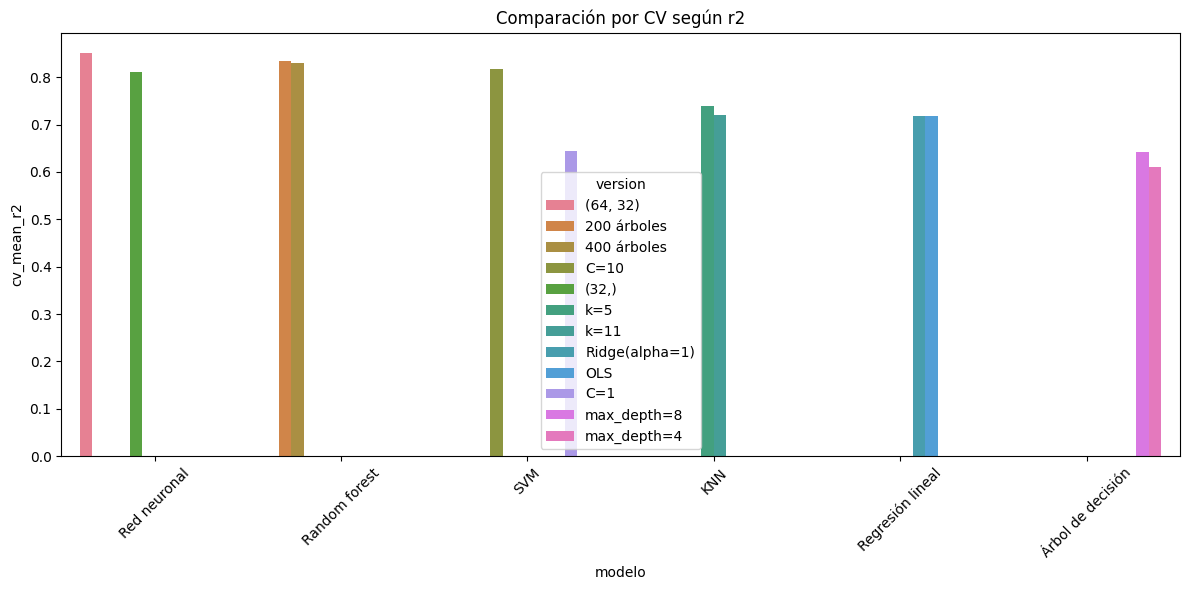

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparacion, x="modelo", y=f"cv_mean_{metrica_principal}", hue="version")
plt.title(f"Comparación por CV según {metrica_principal}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
